
# MNIST: classificação de imagens

## Objetivos de aprendizagem

Ao final desta aula, você deverá ser capaz de:

- compreender o formato do dataset **MNIST em CSV**;
- carregar os arquivos com `pandas.read_csv(...)`;
- separar rótulos e pixels;
- entender como uma imagem 28×28 aparece como 784 colunas em uma tabela;
- reconstruir a imagem a partir dos pixels;
- normalizar os dados;
- transformar a imagem em vetor para Machine Learning clássico;
- treinar um primeiro classificador;
- avaliar o modelo com acurácia, relatório e matriz de confusão.



## 1. Introdução

Nesta versão, vamos usar o **MNIST em formato CSV**, que é mais simples de explicar em aula porque os dados aparecem como uma tabela.

O dataset costuma vir em dois arquivos:

- `mnist_train.csv`
- `mnist_test.csv`

Cada linha representa **uma imagem**.  
Cada linha possui **785 valores**:

- a **primeira coluna** é o rótulo (`label`), isto é, o dígito correto de 0 a 9;
- as **784 colunas restantes** são os pixels da imagem 28 × 28. citeturn687726search0turn687726search6turn687726search8

Isso torna o dataset muito didático para introduzir classificação de imagens com algoritmos clássicos.



## 2. Bibliotecas


In [321]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split




## 3. Carregando os arquivos CSV

> Ajuste os caminhos dos arquivos se necessário.

Nesta aula, assumimos que os arquivos estão no mesmo diretório do notebook:

- `mnist_train.csv`
- `mnist_test.csv`


In [322]:

train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

print("Formato do treino:", train_df.shape)
print("Formato do teste:", test_df.shape)


Formato do treino: (60000, 785)
Formato do teste: (10000, 785)



## 4. Explorando a estrutura da tabela

Vamos observar as primeiras linhas.


In [323]:

train_df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



### Interpretação

- coluna 0: rótulo da imagem
- colunas seguintes: valores dos pixels
- cada pixel assume valor entre 0 e 255

Se o formato estiver correto, o treino terá **785 colunas**:
- 1 coluna de rótulo
- 784 colunas de pixels


In [324]:

print("Número de colunas no treino:", train_df.shape[1])
print("Primeiras colunas:", train_df.columns[:10].tolist())


Número de colunas no treino: 785
Primeiras colunas: ['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9']



## 5. Separando `X` e `y`

Agora vamos separar:

- `y`: rótulos
- `X`: pixels


In [325]:
# Seleciona a primeira coluna (índice 0) do DataFrame de treino,
# que contém os rótulos (dígitos de 0 a 9), e converte para array NumPy
y_train = train_df.iloc[:, 0].values

# Seleciona todas as colunas a partir da segunda (índice 1 em diante),
# que representam os pixels da imagem (784 colunas), e converte para NumPy
X_train = train_df.iloc[:, 1:].values


# Faz o mesmo para o conjunto de teste:
# primeira coluna → rótulos (valores reais)
y_test = test_df.iloc[:, 0].values

# demais colunas → pixels das imagens
X_test = test_df.iloc[:, 1:].values


# Exibe o formato de X_train:
# (número de imagens de treino, 784 pixels por imagem)
print("X_train:", X_train.shape)

# Exibe o formato de y_train:
# (número de rótulos de treino)
print("y_train:", y_train.shape)

# Exibe o formato de X_test:
# (número de imagens de teste, 784 pixels por imagem)
print("X_test:", X_test.shape)

# Exibe o formato de y_test:
# (número de rótulos de teste)
print("y_test:", y_test.shape)


X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)



## 6. Entendendo a imagem como vetor

Cada imagem vem no CSV como uma linha com **784 pixels**.

Ou seja, uma imagem 28 × 28 foi "achatada" em um vetor 1D.

Vamos observar uma amostra.


In [326]:

indice = 2 # imagem qualquer para vermos

print("Rótulo da amostra:", y_train[indice])
print("Tamanho do vetor de pixels:", X_train[indice].shape)
print("Primeiros 20 pixels:", X_train[indice][:20])


Rótulo da amostra: 4
Tamanho do vetor de pixels: (784,)
Primeiros 20 pixels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



## 7. Reconstruindo a imagem 28×28

Para visualizar a imagem, precisamos fazer:

```python
reshape(28, 28)
```


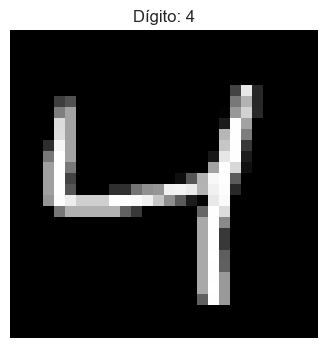

In [327]:

imagem = X_train[indice].reshape(28, 28)

plt.figure(figsize=(4,4))
plt.imshow(imagem, cmap='gray')
plt.title(f"Dígito: {y_train[indice]}")
plt.axis('off')
plt.show()



## 8. Visualizando várias amostras

Essa etapa é importante para conectar a tabela com a ideia de imagem.


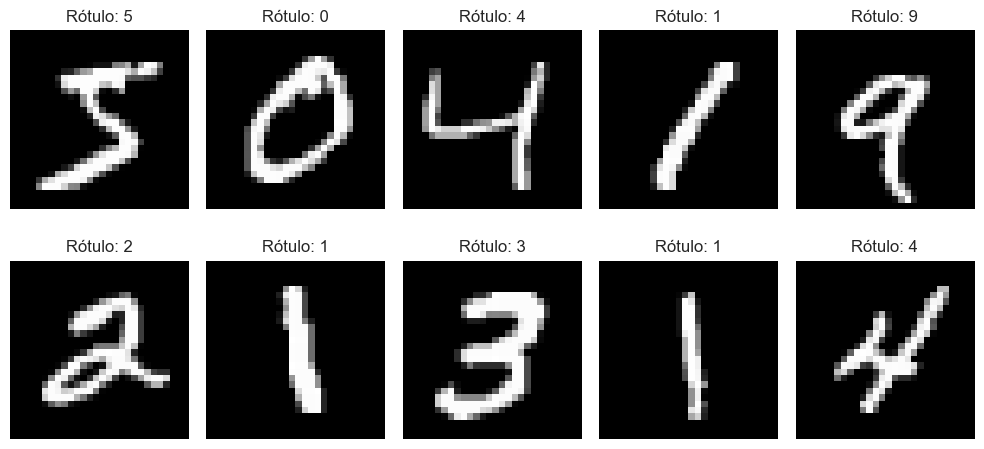

In [328]:

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Rótulo: {y_train[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()



## 9. Normalização dos pixels

Os pixels variam de 0 a 255.  
Uma prática comum é dividir por 255 para trazer os valores ao intervalo [0, 1].

Isso ajuda vários algoritmos a trabalhar de forma mais estável.


In [329]:

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Mínimo em X_train:", X_train.min())
print("Máximo em X_train:", X_train.max())


Mínimo em X_train: 0.0
Máximo em X_train: 1.0



## 10. Relação entre imagem e Machine Learning clássico

Em Deep Learning, podemos manter a estrutura 2D da imagem.  
Mas em Machine Learning clássico, normalmente tratamos cada imagem como um **vetor de atributos**.

Aqui, cada imagem passa a ser:

- 1 amostra
- 784 features


In [330]:

print("Formato usado no treinamento:", X_train.shape)


Formato usado no treinamento: (60000, 784)



## 11. Treinando um primeiro classificador

Vamos usar **Regressão Logística** como primeiro modelo.

Apesar do nome, ela é amplamente utilizada para **classificação**.


In [331]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



## 12. Avaliação do modelo


In [332]:

acc = accuracy_score(y_test, y_pred)
print("Acurácia:", acc)


Acurácia: 0.9261


In [333]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.89       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000




### 12.1 Matriz de confusão

A matriz de confusão mostra em quais dígitos o modelo acerta mais e em quais ele se confunde.


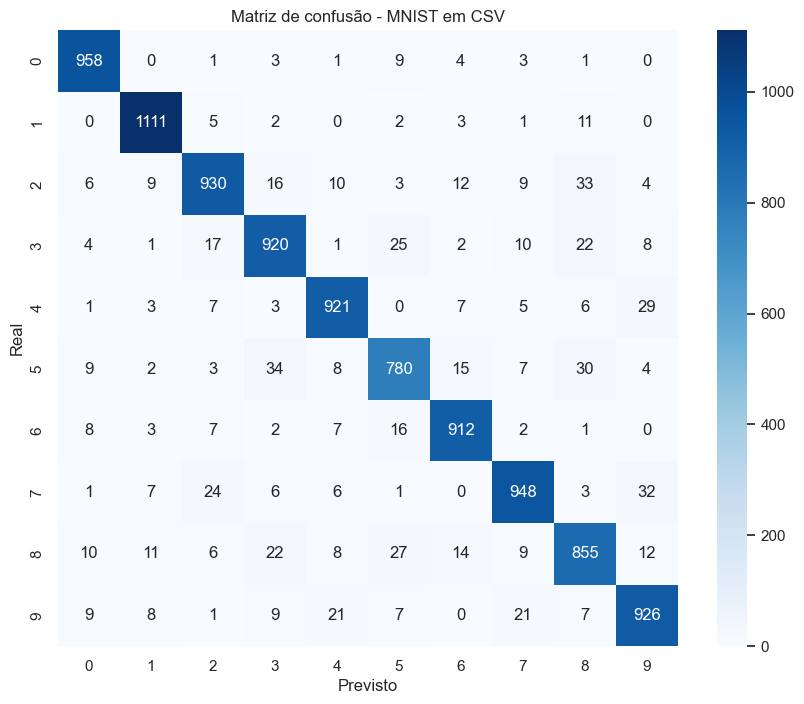

In [334]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão - MNIST em CSV')
plt.show()



## 13. Visualizando erros do modelo

Analisar erros é uma excelente estratégia didática em classificação de imagens.


In [335]:

erros = np.where(y_test != y_pred)[0]
print("Quantidade de erros:", len(erros))


Quantidade de erros: 739


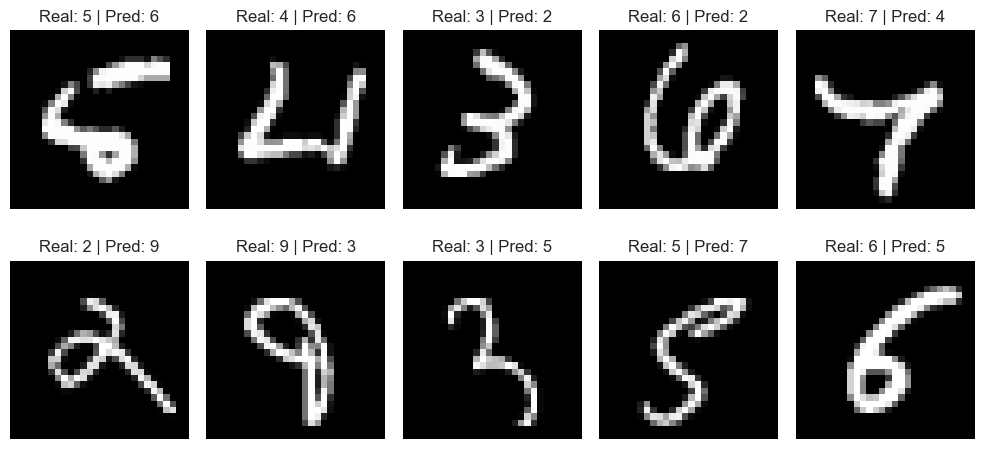

In [336]:

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, idx in zip(axes.flat, erros[:10]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Real: {y_test[idx]} | Pred: {y_pred[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()



## 14. Ligação com os conceitos teóricos

Neste exemplo, temos:

- **aprendizado supervisionado**, porque existe `X` e `y`;
- **classificação multiclasse**, porque há 10 classes possíveis;
- **imagens representadas como vetores numéricos**;
- **pré-processamento simples**, com normalização.

Isso permite conectar o tema de visão computacional com os conceitos de Machine Learning clássico.



## 15. Abordagem baseada em Machine Learning clássico

### Use quando:
- versão simples e tabular do MNIST;
- classificação de imagens sem deep learning;
- trabalhar com `pandas`, `DataFrame` e CSV.

### Limitações:
- trata a imagem como vetor, e não como estrutura espacial 2D;
- modelos clássicos podem ter desempenho inferior a CNNs;



## 16. Exercícios

### Exercício 1
Mostre 20 imagens aleatórias do conjunto de treino com seus rótulos.

### Exercício 2
Treine um `KNeighborsClassifier` e compare com a Regressão Logística.



## 17. Conclusão

O dataset MNIST usamos para:

- leitura de dados com `pandas`;
- separação entre rótulos e atributos;
- representação numérica de imagens;
- classificação multiclasse;
- avaliação de modelos.
